In [6]:
import importlib
import src.arima_model as arima_model

importlib.reload(arima_model)


<module 'src.arima_model' from 'c:\\Users\\Wchet\\margin-returns-forecasting\\src\\arima_model.py'>

In [7]:
from src.arima_model import run_arima


[*********************100%***********************]  1 of 1 completed


Out-of-sample MAE: 0.00920695831895799


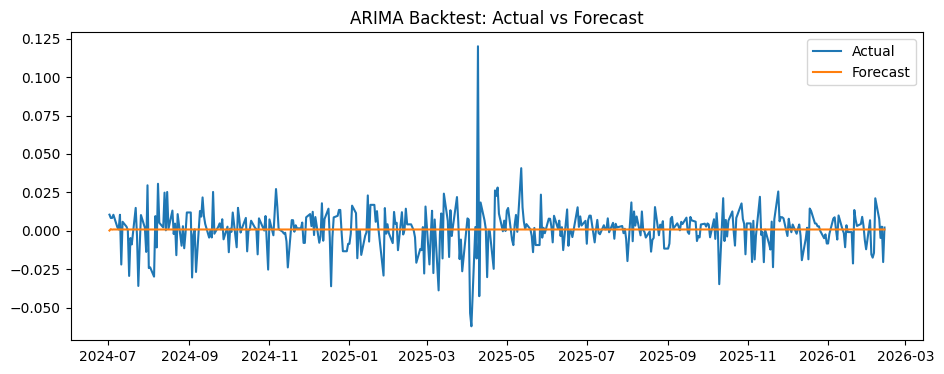

c:\Users\Wchet\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


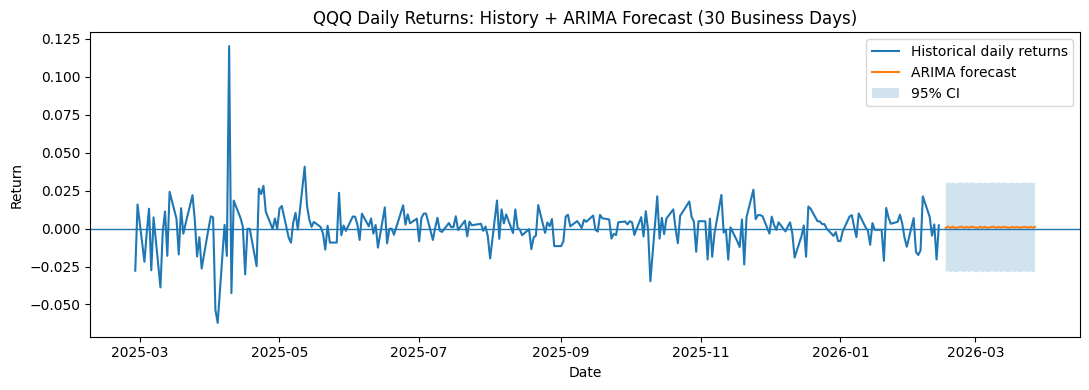

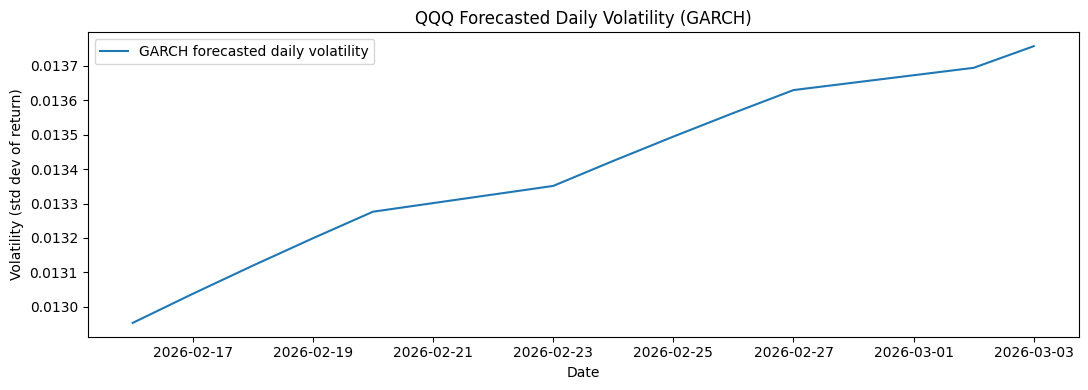

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Allow imports from ../src when running inside /notebooks
sys.path.append(os.path.abspath(".."))

from src.data_prep import get_returns
from src.arima_model import run_arima
from src.volatility_model import run_garch
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1) Load data
# -----------------------------
data = get_returns("QQQ")
returns = data["returns"].dropna()
returns = returns.asfreq("B", method="pad")

# -----------------------------
# 2) Backtest split
# -----------------------------
split = int(len(returns) * 0.8)
train = returns[:split]
test = returns[split:]

# -----------------------------
# 3) ARIMA Backtest Forecast
# -----------------------------
mean_fc, ci = run_arima(train, steps=len(test), order=(2, 0, 2))
test_idx = test.index
mean_fc = pd.Series(mean_fc.values, index=test_idx)

mae = mean_absolute_error(test, mean_fc)
print("Out-of-sample MAE:", mae)

plt.figure(figsize=(11,4))
plt.plot(test.index, test.values, label="Actual")
plt.plot(mean_fc.index, mean_fc.values, label="Forecast")
plt.title("ARIMA Backtest: Actual vs Forecast")
plt.legend()
plt.show()

# -----------------------------
# 4) Future Forecast (30 days)
# -----------------------------
steps = 30
hist = returns.tail(252)
future_idx = pd.bdate_range(start=hist.index[-1] + pd.Timedelta(days=1), periods=steps)

future_mean_fc, future_ci = run_arima(returns, steps=steps, order=(2, 0, 2))
future_mean_fc = pd.Series(future_mean_fc.values, index=future_idx)

future_ci = future_ci.copy()
future_ci.index = future_idx
lower = future_ci.iloc[:, 0].astype(float)
upper = future_ci.iloc[:, 1].astype(float)

# -----------------------------
# 5) Volatility forecast (GARCH)
# -----------------------------
garch_fc = run_garch(returns)

var_12 = garch_fc.variance.iloc[-1].values
vol_12 = (var_12 ** 0.5) / 100.0
vol_steps = min(len(vol_12), steps)
vol_idx = future_idx[:vol_steps]

# -----------------------------
# 6) Plot Future Returns Forecast
# -----------------------------
plt.figure(figsize=(11, 4))
plt.plot(hist.index, hist.values, label="Historical daily returns")
plt.plot(future_mean_fc.index, future_mean_fc.values, label="ARIMA forecast")
plt.fill_between(future_mean_fc.index, lower.values, upper.values, alpha=0.2, label="95% CI")
plt.axhline(0, linewidth=1)
plt.title("QQQ Daily Returns: History + ARIMA Forecast (30 Business Days)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Plot Volatility Forecast
# -----------------------------
plt.figure(figsize=(11, 4))
plt.plot(vol_idx, vol_12[:vol_steps], label="GARCH forecasted daily volatility")
plt.title("QQQ Forecasted Daily Volatility (GARCH)")
plt.xlabel("Date")
plt.ylabel("Volatility (std dev of return)")
plt.legend()
plt.tight_layout()
plt.show()
